In [2]:
# Data Handling Libraries

import pandas as pd
import numpy as np

# Data Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Utilities

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# NLP Libraries (for Customer Remarks)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Word Visualization

from wordcloud import WordCloud

# Ignore Warnings

import warnings
warnings.filterwarnings("ignore")

In [3]:
# downloading the nltk resources
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\H
[nltk_data]     P\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\H
[nltk_data]     P\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
# This code will makes graph look clean and professional
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

## Loading the Dataset

In this step we will:

- Load the ecommerce customer support dataset
- View the dataset structure
- Check number of rows and columns
- Understand column data types

In [5]:
# loading dataset

df = pd.read_csv(r"C:\Users\H P\Desktop\DeepCSAT_ecommerce_using_DL\eCommerce_Customer_support_data.csv")

df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [6]:
# checking dataset shape
df.shape

(85907, 20)

In [7]:
# List of columns present in data
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='str')

In [8]:
# dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

In [9]:
# dataset numerical statistical summary
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


## Checking duplicates and null values

In [10]:
# checking duplicated values
df.duplicated().sum()

np.int64(0)

In [11]:
# checking for missing values
df.isna().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

In [12]:
# calculating percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

Unique id                   0.000000
channel_name                0.000000
category                    0.000000
Sub-category                0.000000
Customer Remarks           66.542889
Order_id                   21.222950
order_date_time            79.962052
Issue_reported at           0.000000
issue_responded             0.000000
Survey_response_Date        0.000000
Customer_City              80.119199
Product_category           79.983005
Item_price                 79.971364
connected_handling_time    99.718300
Agent_name                  0.000000
Supervisor                  0.000000
Manager                     0.000000
Tenure Bucket               0.000000
Agent Shift                 0.000000
CSAT Score                  0.000000
dtype: float64

#### This helps decide whether to drop or fill null values.

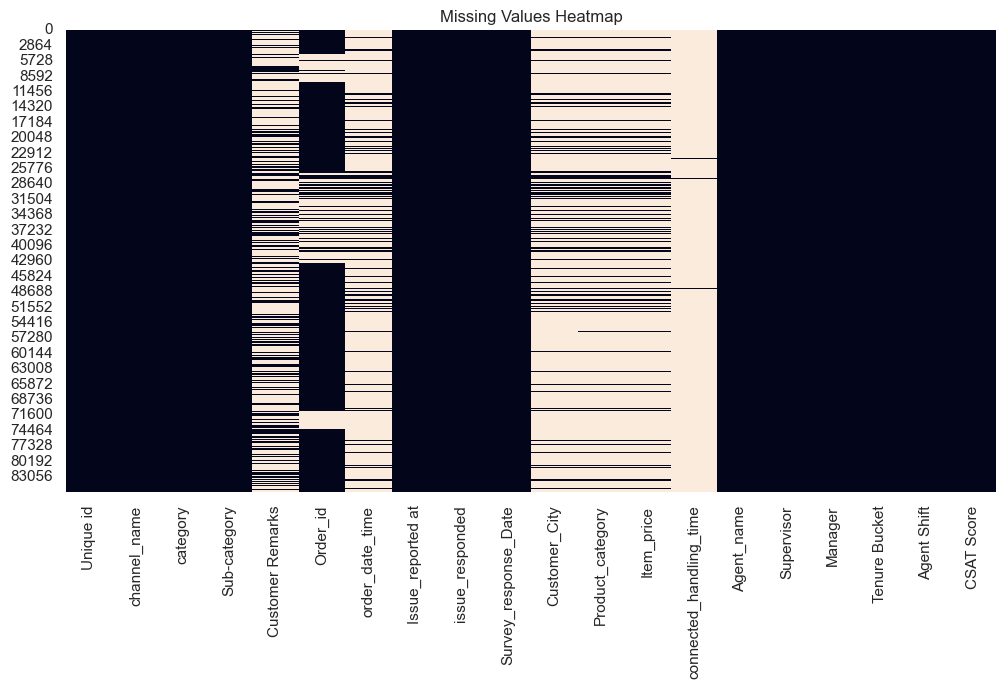

In [13]:
# visualizing missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [14]:
# checking the data types
df.dtypes

Unique id                      str
channel_name                   str
category                       str
Sub-category                   str
Customer Remarks               str
Order_id                       str
order_date_time                str
Issue_reported at              str
issue_responded                str
Survey_response_Date           str
Customer_City                  str
Product_category               str
Item_price                 float64
connected_handling_time    float64
Agent_name                     str
Supervisor                     str
Manager                        str
Tenure Bucket                  str
Agent Shift                    str
CSAT Score                   int64
dtype: object

## Filling and Dropping the missing values with their Data types

In [15]:
# Fill missing text values
df["Customer Remarks"] = df["Customer Remarks"].fillna("No Remark")

# Drop high-missing columns
columns_to_drop = [
    "Order_id",
    "order_date_time",
    "Customer_City",
    "Product_category",
    "Item_price",
    "connected_handling_time"
]

df.drop(columns=columns_to_drop, inplace=True)

# Check dataset again
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Unique id             85907 non-null  str  
 1   channel_name          85907 non-null  str  
 2   category              85907 non-null  str  
 3   Sub-category          85907 non-null  str  
 4   Customer Remarks      85907 non-null  str  
 5   Issue_reported at     85907 non-null  str  
 6   issue_responded       85907 non-null  str  
 7   Survey_response_Date  85907 non-null  str  
 8   Agent_name            85907 non-null  str  
 9   Supervisor            85907 non-null  str  
 10  Manager               85907 non-null  str  
 11  Tenure Bucket         85907 non-null  str  
 12  Agent Shift           85907 non-null  str  
 13  CSAT Score            85907 non-null  int64
dtypes: int64(1), str(13)
memory usage: 9.2 MB


## Convert Date Columns to Datetime

The dataset contains several columns related to time:

- Issue_reported at
- issue_responded
- Survey_response_Date

Currently, these columns are stored as strings (`object` type).  
To perform time calculations, we need to convert them into **datetime format**.

This allows us to:

- Calculate response time
- Analyze delays in customer support
- Create useful features for model training

In [18]:
date_columns = ["Issue_reported at", "issue_responded", "Survey_response_Date"]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")

## Create Response Time Feature

Customer satisfaction often depends on how quickly support responds.

We will calculate **response time** by subtracting:

issue_responded - Issue_reported at

This will tell us how long it took the support team to respond.

In [19]:
# Calculate response time in minutes

df["response_time_minutes"] = (
    df["issue_responded"] - df["Issue_reported at"]
).dt.total_seconds() / 60

## Create Survey Delay Feature

Survey response time indicates how long the customer took to give feedback.

This can sometimes influence satisfaction patterns.

In [20]:
# Calculate survey delay

df["survey_delay_minutes"] = (
    df["Survey_response_Date"] - df["issue_responded"]
).dt.total_seconds() / 60

## Verifying New Features

After creating new features, we check the dataset to confirm that the new columns were added correctly.

In [21]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Issue_reported at,issue_responded,Survey_response_Date,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_minutes,survey_delay_minutes
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remark,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0,-707.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remark,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0,-774.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remark,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0,-1238.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remark,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0,-1276.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remark,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0,-632.0


## Check New Column Types

Ensure the newly created columns are numeric so they can be used for analysis and modeling.

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unique id              85907 non-null  str           
 1   channel_name           85907 non-null  str           
 2   category               85907 non-null  str           
 3   Sub-category           85907 non-null  str           
 4   Customer Remarks       85907 non-null  str           
 5   Issue_reported at      85907 non-null  datetime64[us]
 6   issue_responded        85907 non-null  datetime64[us]
 7   Survey_response_Date   85907 non-null  datetime64[us]
 8   Agent_name             85907 non-null  str           
 9   Supervisor             85907 non-null  str           
 10  Manager                85907 non-null  str           
 11  Tenure Bucket          85907 non-null  str           
 12  Agent Shift            85907 non-null  str           
 13  CSAT Score  

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the dataset and discover patterns
that may influence the **Customer Satisfaction Score (CSAT)**.

We will analyze the data using:

Univariate Analysis
- Distribution of CSAT Score
- Distribution of Channels
- Distribution of Categories
- Distribution of Agent Shift

Bivariate Analysis
- CSAT Score vs Channel
- CSAT Score vs Category
- CSAT Score vs Tenure Bucket
- Response Time vs CSAT

Multivariate Analysis
- Correlation Heatmap
- Pairplot

### Univariate Analysis
Univariate analysis examines **one variable at a time** to understand its distribution and characteristics.

### Distribution of CSAT Score

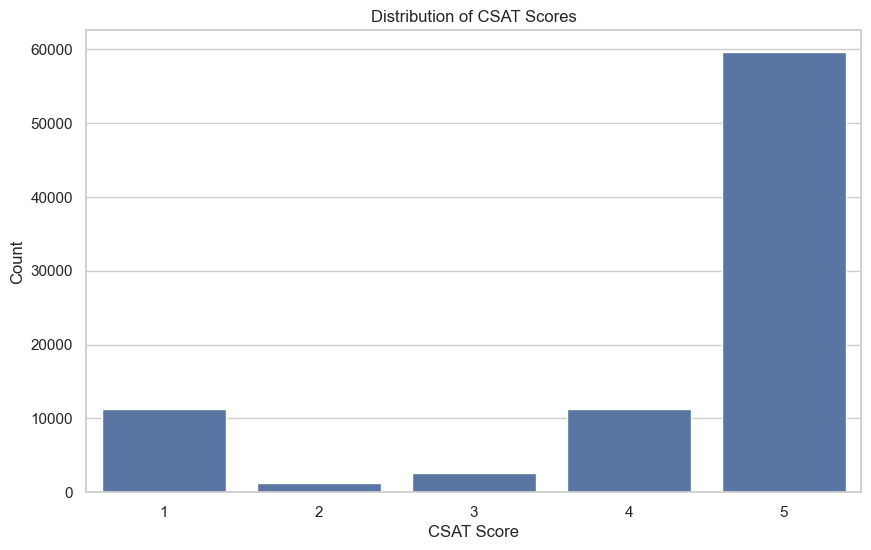

In [23]:
sns.countplot(x="CSAT Score", data=df)

plt.title("Distribution of CSAT Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

plt.show()

This analysis shows how customer satisfaction scores are distributed.

Business Insight:
Understanding the distribution of CSAT scores helps identify whether
customers are generally satisfied or dissatisfied with the service.

### Distribution of Customer Support Channels

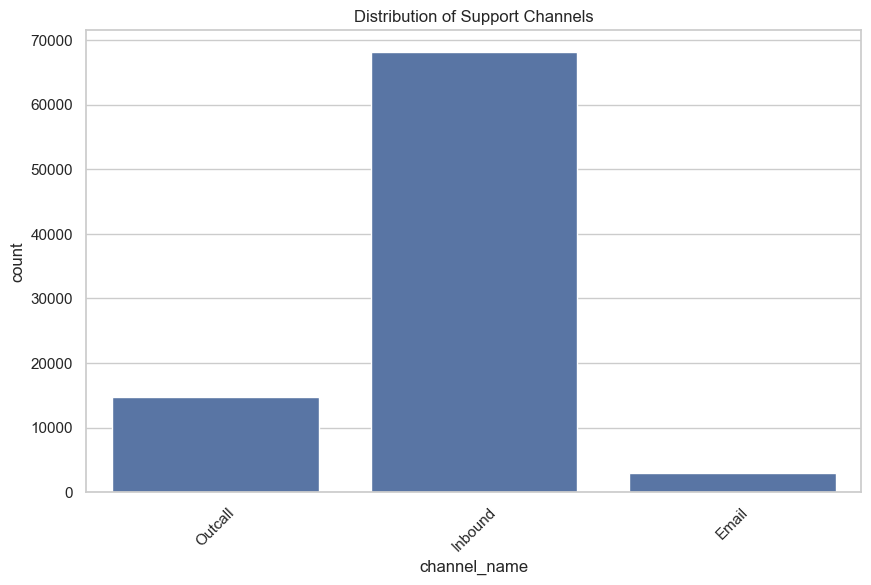

In [24]:
sns.countplot(x="channel_name", data=df)

plt.title("Distribution of Support Channels")
plt.xticks(rotation=45)

plt.show()

Customers may contact support through different channels such as
chat, email, or phone.

Business Insight:
This analysis shows which communication channels customers prefer.
Companies can allocate more resources to the most used channels.

### Distribution of Issue Categories

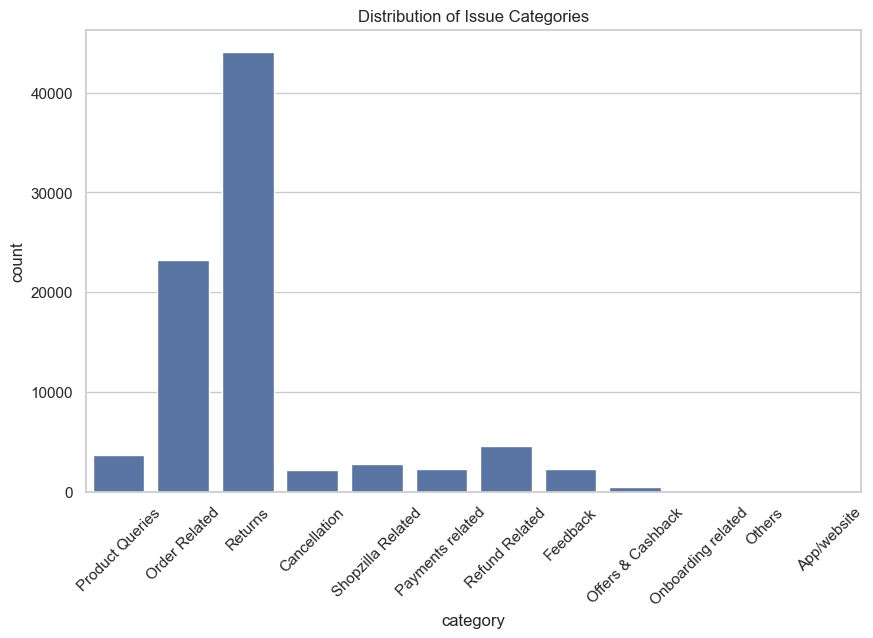

In [25]:
sns.countplot(x="category", data=df)

plt.title("Distribution of Issue Categories")
plt.xticks(rotation=45)

plt.show()

This analysis shows the types of issues reported by customers.

Business Insight:
Understanding the most frequent issue categories helps businesses
identify recurring problems and improve product or service quality.

### Distribution of Agent Shifts

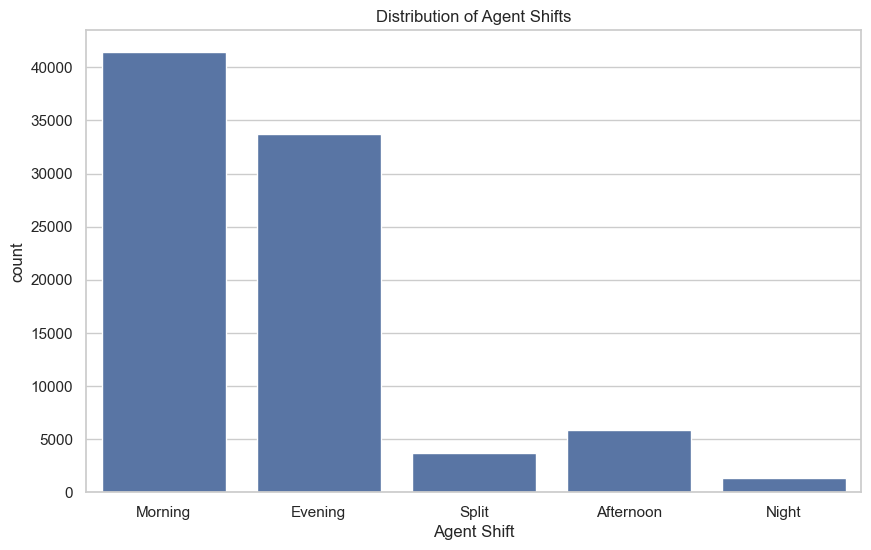

In [26]:
sns.countplot(x="Agent Shift", data=df)

plt.title("Distribution of Agent Shifts")
plt.show()

Customer support agents work in different shifts.

Business Insight:
Analyzing shift distribution helps determine whether certain shifts
handle more customer queries than others.

### Bivariate Analysis
Bivariate analysis examines the relationship between **two variables**
to understand how one variable affects another.

### CSAT Score vs Channel

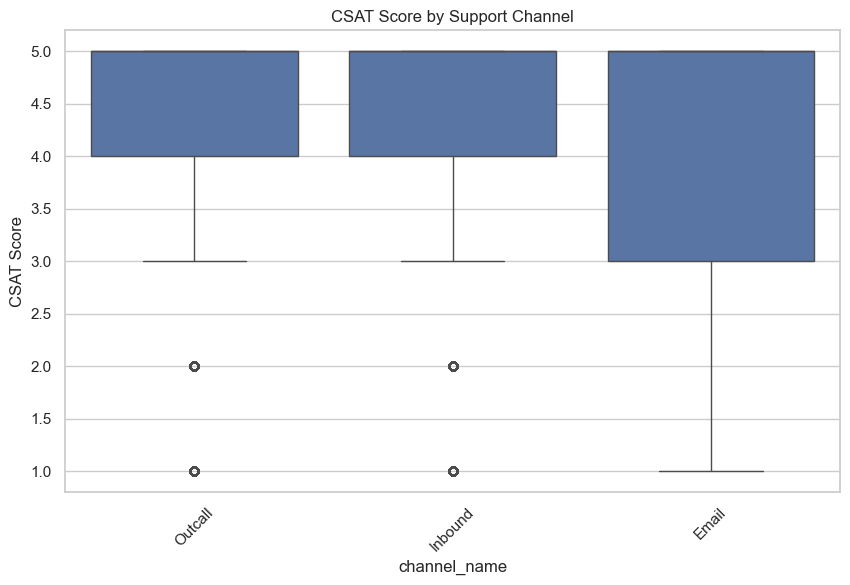

In [27]:
sns.boxplot(x="channel_name", y="CSAT Score", data=df)

plt.title("CSAT Score by Support Channel")
plt.xticks(rotation=45)

plt.show()

This analysis examines how customer satisfaction varies across
different communication channels.

Business Insight:
If one channel consistently receives lower CSAT scores,
it may indicate slower response times or poor service quality
in that channel.

### CSAT Score vs Issue Category

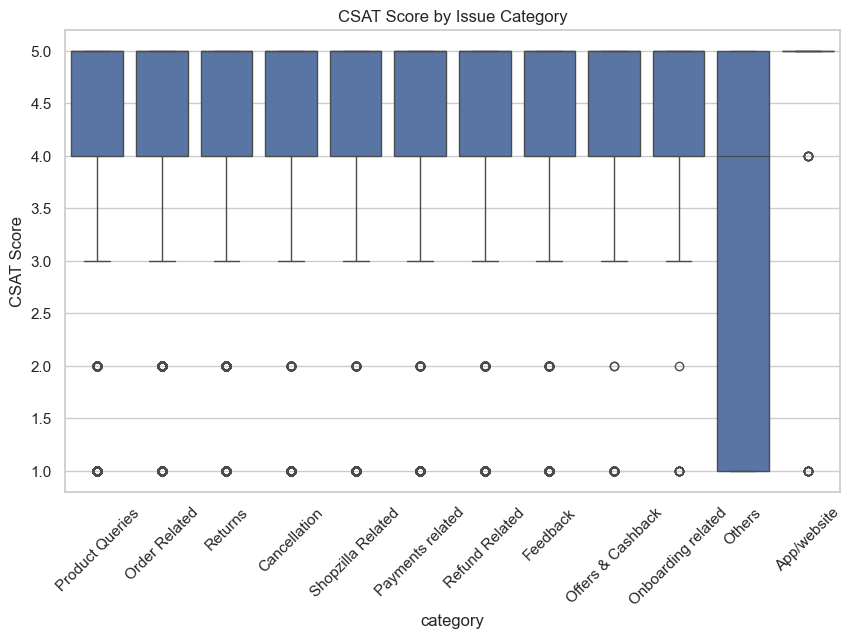

In [28]:
sns.boxplot(x="category", y="CSAT Score", data=df)

plt.title("CSAT Score by Issue Category")
plt.xticks(rotation=45)

plt.show()

Different types of issues may lead to different satisfaction levels.

Business Insight:
Certain issue categories may result in lower satisfaction scores,
indicating that these problems are harder to resolve.

### CSAT Score vs Agent Tenure

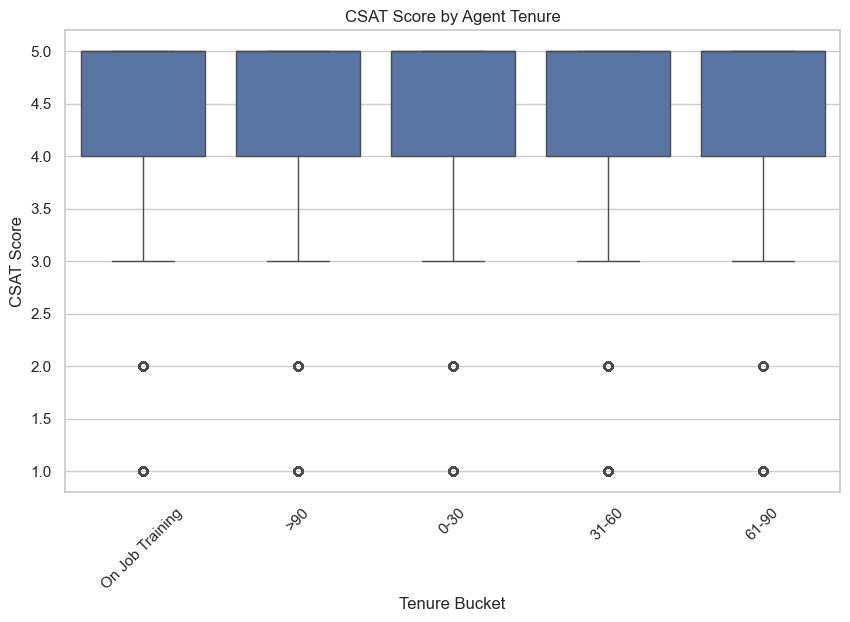

In [29]:
sns.boxplot(x="Tenure Bucket", y="CSAT Score", data=df)

plt.title("CSAT Score by Agent Tenure")
plt.xticks(rotation=45)

plt.show()

Agent experience may influence customer satisfaction.

Business Insight:
More experienced agents may resolve issues faster,
leading to higher customer satisfaction.

### Response Time vs CSAT Score

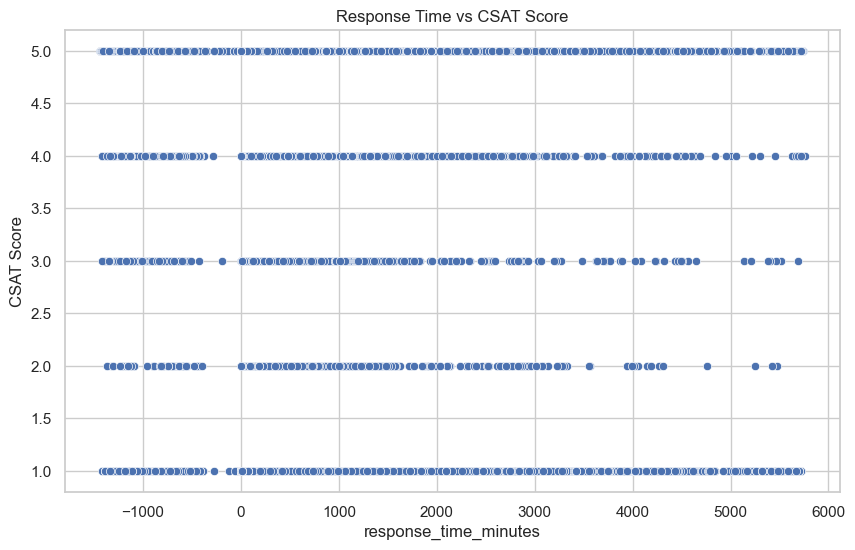

In [30]:
sns.scatterplot(x="response_time_minutes", y="CSAT Score", data=df)

plt.title("Response Time vs CSAT Score")
plt.show()

Customer satisfaction often depends on how quickly
support agents respond to issues.

Business Insight:
Long response times may result in lower CSAT scores.
This analysis helps determine whether faster response
times lead to higher satisfaction.

### Multivariate Analysis
Multivariate analysis examines relationships between
multiple variables simultaneously.

### Correlation Heatmap

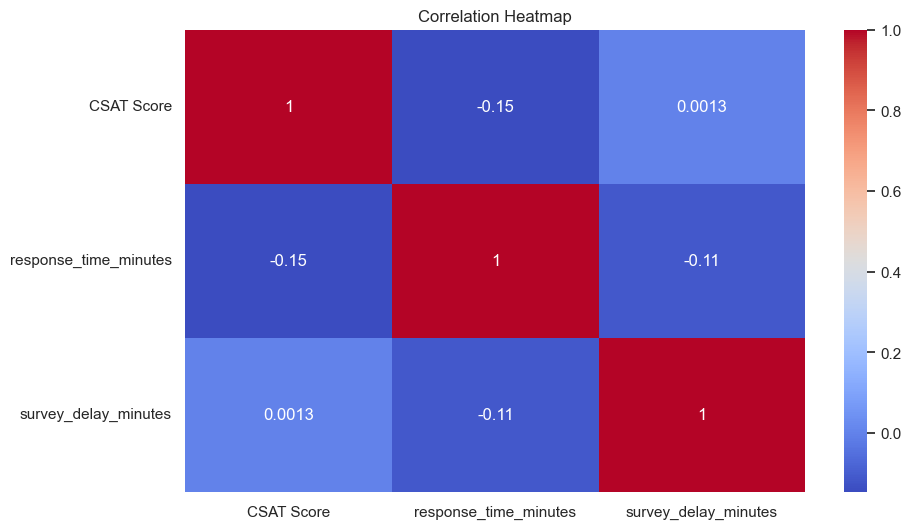

In [31]:
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

A heatmap shows the correlation between numerical variables.

Business Insight:
Strong correlations between variables may indicate
important factors affecting customer satisfaction.

### Pairplot of Numerical Features

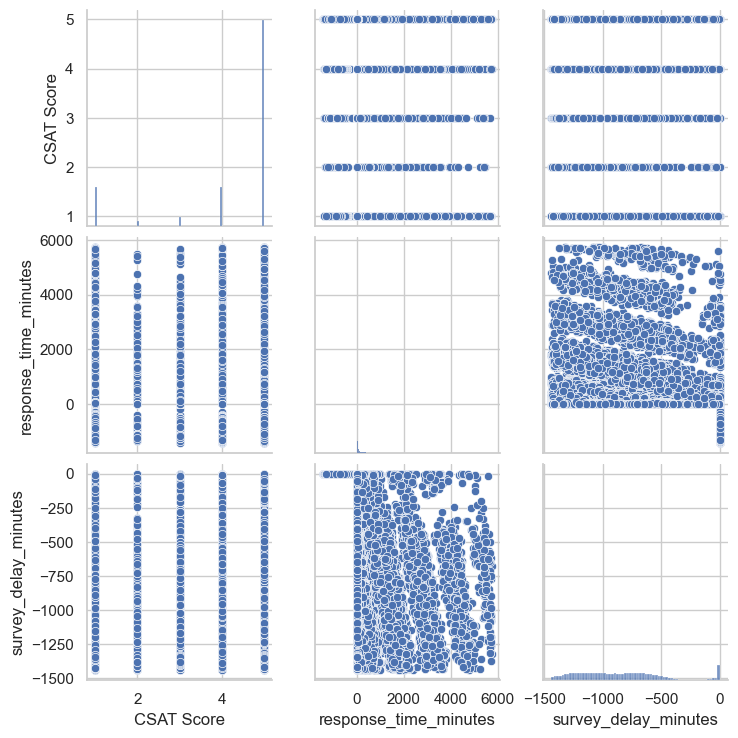

In [32]:
sns.pairplot(numeric_df)

plt.show()

Pairplots visualize relationships between multiple numerical variables.

Business Insight:
This helps identify patterns, clusters, and potential relationships
between features that may influence CSAT scores.

### Summary of EDA Insights

From the exploratory analysis I can observe:

- Distribution of customer satisfaction scores
- Most frequently used support channels
- Most common issue categories
- Relationship between response time and satisfaction
- Impact of agent experience on customer satisfaction

These insights help identify important factors
that influence customer satisfaction and guide
feature engineering for model development.

## Feature Engineering

Feature engineering involves creating new variables from existing data
to improve the performance of machine learning models.

In this step we will:

- Create response time categories
- Create survey delay categories
- Extract useful time features
- Prepare features for modeling

### Response Time Buckets

Response time plays a critical role in customer satisfaction.

Customers who receive faster responses are generally more satisfied.

We categorize response time into different buckets to better capture
the relationship between response speed and CSAT score.

In [33]:
df["response_time_bucket"] = pd.cut(
    df["response_time_minutes"],
    bins=[0, 10, 30, 60, 120, 10000],
    labels=["Very Fast", "Fast", "Moderate", "Slow", "Very Slow"]
)

df["response_time_bucket"].value_counts()

response_time_bucket
Very Fast    47653
Very Slow    14172
Fast         10135
Moderate      4484
Slow          3887
Name: count, dtype: int64

### Survey Delay Buckets

Survey delay represents the time taken by customers to respond to the survey.

This may indicate the level of engagement or satisfaction of the customer.

In [34]:
df["survey_delay_bucket"] = pd.cut(
    df["survey_delay_minutes"],
    bins=[0, 30, 120, 360, 1440, 10000],
    labels=["Immediate", "Short Delay", "Moderate Delay", "Long Delay", "Very Long Delay"]
)

df["survey_delay_bucket"].value_counts()

survey_delay_bucket
Immediate          0
Short Delay        0
Moderate Delay     0
Long Delay         0
Very Long Delay    0
Name: count, dtype: int64

### Extract Time-Based Features

We extract useful time features from the issue reported timestamp.

These features help us understand when most issues occur.

In [35]:
df["issue_hour"] = df["Issue_reported at"].dt.hour
df["issue_day"] = df["Issue_reported at"].dt.day
df["issue_month"] = df["Issue_reported at"].dt.month

df[["issue_hour","issue_day","issue_month"]].head()

,issue_hour,issue_day,issue_month
0,11,1,8
1,12,1,8
2,20,1,8
3,20,1,8
4,10,1,8


### Day of Week Feature

Customer support load may vary depending on the day of the week.

This feature helps analyze whether weekends or weekdays
impact customer satisfaction.

In [36]:
df["issue_day_of_week"] = df["Issue_reported at"].dt.day_name()

df["issue_day_of_week"].value_counts()

issue_day_of_week
Tuesday      14282
Thursday     13803
Wednesday    13633
Monday       12053
Sunday       10942
Saturday     10630
Friday       10564
Name: count, dtype: int64

### Drop Original Date Columns

After extracting useful features from the date columns,
the original columns are no longer needed for modeling.

In [37]:
df.drop(
    ["Issue_reported at", "issue_responded", "Survey_response_Date"],
    axis=1,
    inplace=True
)

### Verify Dataset After Feature Engineering

We check the dataset structure to confirm that
all new features have been created successfully.

In [38]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_minutes,survey_delay_minutes,response_time_bucket,survey_delay_bucket,issue_hour,issue_day,issue_month,issue_day_of_week
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remark,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0,-707.0,Moderate,NaN,11,1,8,Tuesday
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remark,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0,-774.0,Very Fast,NaN,12,1,8,Tuesday
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remark,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0,-1238.0,Fast,NaN,20,1,8,Tuesday
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remark,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0,-1276.0,Fast,NaN,20,1,8,Tuesday
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remark,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0,-632.0,Very Fast,NaN,10,1,8,Tuesday


These new features help the model understand:

- how response time affects satisfaction

- when issues are reported

- how quickly customers respond to surveys

## Data Preprocessing

Before training a machine learning model, the dataset must be prepared.

In this step we will:

- Clean and process customer remarks (text data)
- Convert categorical variables into numerical format
- Scale numerical features
- Prepare input features (X) and target variable (y)

### Text Preprocessing

Customer remarks contain textual feedback from customers.

Text preprocessing helps remove unnecessary elements such as:

- punctuation
- stopwords
- special characters

This improves the quality of features used in the model.

In [39]:
import re

def clean_text(text):
    
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stopwords.words("english")]
    
    return " ".join(words)

df["cleaned_remarks"] = df["Customer Remarks"].apply(clean_text)

df[["Customer Remarks","cleaned_remarks"]].head()

,Customer Remarks,cleaned_remarks
0,No Remark,remark
1,No Remark,remark
2,No Remark,remark
3,No Remark,remark
4,No Remark,remark


### Convert Text to Numerical Features

Machine learning models cannot understand text directly.

We convert the cleaned remarks into numerical vectors using
TF-IDF (Term Frequency – Inverse Document Frequency).

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)

text_features = tfidf.fit_transform(df["cleaned_remarks"])

text_features.shape

(85907, 1000)

### Encoding Categorical Variables

Machine learning models require numerical input.

Categorical variables such as channel name, category,
and agent shift are converted into numerical values
using label encoding.

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
    "channel_name",
    "category",
    "Sub-category",
    "Agent_name",
    "Supervisor",
    "Manager",
    "Tenure Bucket",
    "Agent Shift",
    "response_time_bucket",
    "survey_delay_bucket",
    "issue_day_of_week"
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

### Selecting Numerical Features

We combine numerical features and encoded categorical features
to create the final dataset used for model training.

In [42]:
numerical_features = [
    "response_time_minutes",
    "survey_delay_minutes",
    "issue_hour",
    "issue_day",
    "issue_month"
]

X_numeric = df[numerical_features]

### Combine All Features

Text features and structured features are combined to create
the final feature matrix.

In [43]:
from scipy.sparse import hstack

X = hstack((text_features, X_numeric))

### Target Variable

The target variable is the Customer Satisfaction Score (CSAT).

In [44]:
y = df["CSAT Score"]

## Train Test Split

The dataset is divided into training and testing sets.

Training data is used to train the model, while testing data
is used to evaluate its performance.

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

Feature scaling ensures that numerical features are on
a similar scale, which helps machine learning models
perform better.

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Data preprocessing completed:

- Cleaned customer remarks
- Converted text into TF-IDF features
- Encoded categorical variables
- Combined numerical and text features
- Created training and testing datasets

## Preparing Data for Deep Learning

Deep learning models require numerical input.

In this step we will:

- Convert customer remarks into sequences using tokenization
- Apply padding so that all text inputs have the same length
- Prepare structured features
- Split the dataset into training and testing sets

### Importing Deep Learning Libraries

In [47]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### Text Tokenization

Tokenization converts words into numerical indices.

Each unique word in the dataset is assigned a number.
This allows the deep learning model to process text data.

In [48]:
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(df["cleaned_remarks"])

text_sequences = tokenizer.texts_to_sequences(df["cleaned_remarks"])

### Sequence Padding

Text sequences have different lengths.

Padding ensures that all sequences have the same length
so they can be processed by deep learning models.

In [49]:
max_length = 100

text_padded = pad_sequences(
    text_sequences,
    maxlen=max_length,
    padding="post"
)

### Structured Features

Apart from text data, the dataset also contains structured features
such as response time and issue timing.

These features are included to improve model performance.

In [50]:
structured_features = df[
    [
        "response_time_minutes",
        "survey_delay_minutes",
        "issue_hour",
        "issue_day",
        "issue_month"
    ]
].values

### target Variable

In [51]:
y = df["CSAT Score"].values

### Train Test Split

In [52]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    text_padded,
    structured_features,
    y,
    test_size=0.2,
    random_state=42
)

### Deep learning data preparation completed:

- Tokenized customer remarks
- Converted text to sequences
- Applied sequence padding
- Prepared structured numerical features
- Created training and testing datasets

## Build Deep Learning Model

In this step we will build a hybrid deep learning model.

The model will use:

- Text data (Customer Remarks)
- Structured numerical features

The text data will pass through an Embedding and LSTM layer,
while structured features will pass through Dense layers.
Both outputs will then be combined to predict CSAT Score.

### Importing Deep Learning Libraries

In [53]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate, Dropout

### Text Input Layer

The text input layer receives tokenized customer remarks.
An embedding layer converts words into dense vector representations.

In [54]:
text_input = Input(shape=(max_length,))

### Emnedding Layer
Embedding converts words into dense vector representations.

In [55]:
embedding = Embedding(
    input_dim=10000,
    output_dim=128,
    input_length=max_length
)(text_input)

### LSTM Layer

LSTM (Long Short-Term Memory) captures sequential patterns in text.

This helps the model understand the context of customer remarks.

In [56]:
lstm_layer = LSTM(64)(embedding)

### Structured Feature Input

Structured features such as response time and issue timing
are passed through dense layers.

In [57]:
structured_input = Input(shape=(structured_features.shape[1],))

### Dense Layer for Structured Data

In [58]:
structured_dense = Dense(32, activation="relu")(structured_input)

### Feature Fusion

Outputs from the text branch and structured branch are combined
using concatenation.

In [59]:
combined = Concatenate()([lstm_layer, structured_dense])

In [60]:
# Final Dense Layer
dense1 = Dense(64, activation="relu")(combined)
drop1 = Dropout(0.3)(dense1)

dense2 = Dense(32, activation="relu")(drop1)

### Output Layer
Since CSAT score is 1-5 classification, I use softmax

In [61]:
output = Dense(5, activation="softmax")(dense2)

In [62]:
# Build Model
model = Model(
    inputs=[text_input, structured_input],
    outputs=output
)

### Compile Model

We use:

- optimizer: Adam
- loss: sparse categorical crossentropy
- metric: accuracy

In [63]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [64]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     49,408 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        192 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        165 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,338,053 (5.10 MB)

 Trainable params: 1,338,053 (5.10 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

The model is trained using the training dataset.

In [65]:
history = model.fit(
    [X_text_train, X_struct_train],
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\H P\Desktop\DeepCSAT_ecommerce_using_DL\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\H P\Desktop\DeepCSAT_ecommerce_using_DL\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\H P\Desktop\DeepCSAT_ecommerce_using_DL\.venv\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "c:\Users\H P\Desktop\DeepCSAT_ecommerce_using_DL\.venv\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "C:\Program Files\Python311\Lib\asyncio\base_events.py", line 604, in run_forever

  File "C:\Program Files\Python311\Lib\asyncio\base_event

### Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(
    [X_text_test, X_struct_test],
    y_test
)

print("Test Accuracy:", accuracy)